# Lightweight IDS Using Machine Learning for IoT Devices
## Notebook 04: IDS Prototype

**Author:** Mimi Nguyet Mi Taylor  
**Programme:** MSc Computer Science, Birkbeck, University of London  
**Supervisor:** Professor Paul Yoo

---

### About this notebook
This notebook implements a lightweight Intrusion Detection System (IDS) prototype
using the Decision Tree classifier trained in Notebook 03. Decision Tree was selected
as the most suitable classifier for IoT deployment because it offers the best
trade-off between detection accuracy (macro F1 0.57) and resource efficiency
(model size 14,391 KB, inference time 0.0002ms per record), as discussed in
Notebook 03.

This notebook demonstrates deployment feasibility (O6) in two stages:

1. **Live traffic simulation:** a small sample of test records is classified
   one at a time, as if arriving at an IoT device in real time. This is a
   qualitative demonstration of how the prototype would behave in deployment.
2. **Full evaluation:** the complete test set is classified in a single batch
   to produce statistically meaningful detection results, a confusion matrix,
   and a saved CSV of outcomes.

### Input
- model_Decision_Tree.pkl
- X_test.pkl
- y_test.pkl

### Output
- prototype_predictions.csv
- prototype_detection_summary.csv
- chart_confusion_matrix.png

In [1]:
# Import all libraries needed for this notebook.
# joblib: loading the saved Decision Tree model and test data
# pandas/numpy: data handling
# time: measuring simulated real-time classification
# matplotlib/seaborn: confusion matrix visualisation
# sklearn.metrics: confusion matrix and classification report

import pandas as pd
import numpy as np
import time
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

OUTPUT_DIR = os.path.expanduser("~/IDS_PROJECT_REPORT/")

print("All imports successful.")

All imports successful.


In [2]:
# Load the trained Decision Tree model from Notebook 03, and the
# original unmodified test set from Notebook 02.
# X_test and y_test were never resampled with SMOTE-ENN, so they
# represent realistic, naturally-distributed traffic, which is the
# correct data to demonstrate a deployed prototype against.

clf = joblib.load(OUTPUT_DIR + "model_Decision_Tree.pkl")
X_test = joblib.load(OUTPUT_DIR + "X_test.pkl")
y_test = joblib.load(OUTPUT_DIR + "y_test.pkl")

print(f"Model loaded: {type(clf).__name__}")
print(f"Test set: {X_test.shape[0]:,} records, {X_test.shape[1]} features")

Model loaded: DecisionTreeClassifier
Test set: 219,362 records, 13 features


---
## Part 1: Live Traffic Simulation

To demonstrate deployment feasibility, a small random sample of test records
is classified one record at a time, with each classification printed as it
happens. This mimics how the prototype would behave on an IoT device
receiving a continuous stream of network traffic, rather than a single
batch prediction.

A fixed random seed is used so the same sample is selected every time the
notebook is run, keeping results reproducible for the report.

In [3]:
# Select a small random sample of 50 records to simulate live traffic.
# random_state ensures the same sample is drawn every time this notebook
# is re-run, so the demonstration is reproducible.

SAMPLE_SIZE = 50
sample_indices = X_test.sample(n=SAMPLE_SIZE, random_state=42).index

X_sample = X_test.loc[sample_indices]
y_sample = y_test.loc[sample_indices]

print(f"Selected {SAMPLE_SIZE} records to simulate live traffic arriving at an IoT device.")

Selected 50 records to simulate live traffic arriving at an IoT device.


In [4]:
# Classify each record individually and print the result as it happens.
# Each prediction is timed separately to show that classification is fast
# enough for real-time use, which is the central claim of the prototype.
#
# time.sleep() is intentionally NOT used here so the notebook runs quickly
# and reproducibly. Uncomment the sleep line below if a slower, more
# visually realistic live demo is needed.

correct_count = 0

for i, idx in enumerate(sample_indices, start=1):
    record = X_sample.loc[[idx]]
    actual = y_sample.loc[idx]

    start = time.time()
    predicted = clf.predict(record)[0]
    elapsed_ms = (time.time() - start) * 1000

    is_correct = predicted == actual
    correct_count += int(is_correct)
    status = "OK" if is_correct else "MISCLASSIFIED"

    print(f"Record {i:2d} | Predicted: {predicted:<15} | Actual: {actual:<15} | "
          f"{elapsed_ms:.4f} ms | {status}")
    # time.sleep(0.5)  # uncomment for a slower, more visual live demo

print(f"\n{correct_count}/{SAMPLE_SIZE} records correctly classified in this simulation.")

Record  1 | Predicted: DoS             | Actual: DoS             | 7.5850 ms | OK
Record  2 | Predicted: DoS             | Actual: DoS             | 0.3338 ms | OK
Record  3 | Predicted: DoS             | Actual: DDoS            | 0.2401 ms | MISCLASSIFIED
Record  4 | Predicted: DDoS            | Actual: DDoS            | 0.2191 ms | OK
Record  5 | Predicted: DDoS            | Actual: DDoS            | 0.2160 ms | OK
Record  6 | Predicted: DoS             | Actual: DoS             | 0.2091 ms | OK
Record  7 | Predicted: DDoS            | Actual: DDoS            | 0.2079 ms | OK
Record  8 | Predicted: Mirai           | Actual: Mirai           | 0.2029 ms | OK
Record  9 | Predicted: DDoS            | Actual: DoS             | 0.2012 ms | MISCLASSIFIED
Record 10 | Predicted: DDoS            | Actual: DoS             | 0.2062 ms | MISCLASSIFIED
Record 11 | Predicted: DoS             | Actual: DoS             | 0.2058 ms | OK
Record 12 | Predicted: DDoS            | Actual: DDoS            

---
## Part 2: Full Test Set Evaluation

The live simulation above is illustrative, not statistically meaningful on
its own (50 records is too small a sample to draw conclusions from). The
full test set is now classified in a single batch to produce results that
can actually be reported and analysed.

In [5]:
# Classify the entire test set in one batch.
# This is the same operation Notebook 03 already timed for resource
# efficiency; here the focus is on the classification outcomes themselves,
# not the timing.

y_pred = clf.predict(X_test)

print(f"Classified {len(X_test):,} records.")

Classified 219,362 records.


In [6]:
# Build a per-record results table showing actual category, predicted
# category, and whether the prediction was correct. This is the prototype's
# core output: a structured record of every classification decision made,
# which is what a real IDS log would look like.

results_df = pd.DataFrame({
    'Actual Category': y_test.values,
    'Predicted Category': y_pred,
})
results_df['Correct'] = results_df['Actual Category'] == results_df['Predicted Category']

results_df.to_csv(OUTPUT_DIR + "prototype_predictions.csv", index=False)

print("Per-record predictions saved to prototype_predictions.csv")
results_df.head(10)

Per-record predictions saved to prototype_predictions.csv


,Actual Category,Predicted Category,Correct
0,DoS,DoS,True
1,Mirai,Mirai,True
2,DDoS,DDoS,True
3,DDoS,DDoS,True
4,Benign,Benign,True
5,DoS,DoS,True
6,DDoS,DDoS,True
7,Mirai,Mirai,True
8,DDoS,DoS,False
9,Mirai,Mirai,True


In [7]:
# Summarise detection performance per attack category.
# This shows, for each category, how many records were seen, how many
# were correctly detected, and the resulting detection rate (recall).
# This is the key results table for the report, since it directly answers
# the question: "does the prototype actually detect each attack type?"

summary_rows = []

for category in sorted(y_test.unique()):
    mask = results_df['Actual Category'] == category
    total = mask.sum()
    correct = results_df.loc[mask, 'Correct'].sum()
    detection_rate = correct / total if total > 0 else 0

    summary_rows.append({
        'Attack Category': category,
        'Total Records': total,
        'Correctly Detected': correct,
        'Detection Rate': round(detection_rate, 4)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR + "prototype_detection_summary.csv", index=False)

print("Detection summary saved to prototype_detection_summary.csv")
print(summary_df.to_string(index=False))

Detection summary saved to prototype_detection_summary.csv
Attack Category  Total Records  Correctly Detected  Detection Rate
         Benign           7003                5100          0.7283
    Brute Force             83                   6          0.0723
           DDoS         146204              109239          0.7472
            DoS          41744               25061          0.6003
          Mirai          16763               16726          0.9978
 Reconnaissance           4402                2744          0.6234
       Spoofing           3004                2379          0.7919
      Web-based            159                  22          0.1384


---
## Part 3: Confusion Matrix

The detection summary above shows how many records of each category were
correctly identified, but it does not show what an incorrect prediction was
mistaken for. A confusion matrix adds this detail: each row represents the
actual category, each column represents what the prototype predicted, so
off-diagonal cells reveal exactly which categories are confused with which.

This matters for the report's discussion of limitations. For example, if
Brute Force records are frequently predicted as Benign, that is a more
serious deployment concern than if they are simply misclassified as a
different attack category, since it means real attacks would go
undetected entirely rather than being flagged under the wrong label.

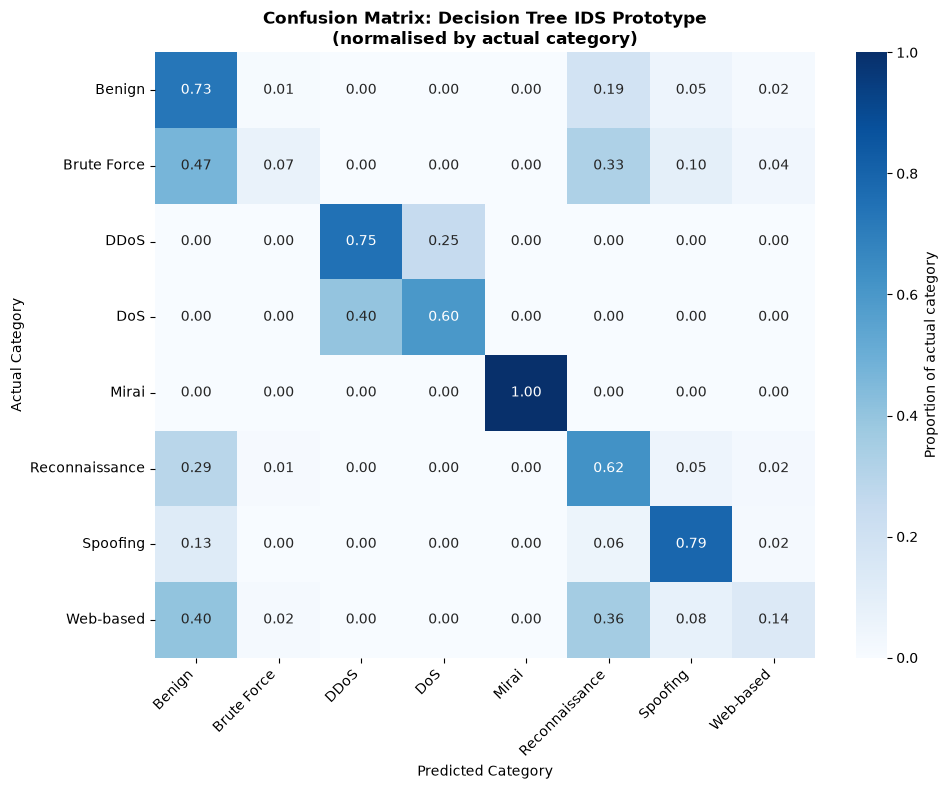

Confusion matrix chart saved.


In [8]:
# Compute the confusion matrix across all categories.
# Rows = actual category, Columns = predicted category.
# Values are normalised by row (i.e. by actual category) so that each row
# sums to 1. This is used instead of raw counts because class sizes vary
# greatly (e.g. DDoS has far more records than Brute Force), and raw
# counts would make rare categories look empty even if detection is poor.

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            cbar_kws={'label': 'Proportion of actual category'})
plt.title('Confusion Matrix: Decision Tree IDS Prototype\n(normalised by actual category)',
          fontweight='bold')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "chart_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix chart saved.")

---
## Summary

| Step | Description | Result |
|------|-------------|--------|
| Load | Trained Decision Tree model and test set loaded from Notebooks 02/03 | 219,362 test records |
| Simulate | 50 records classified one at a time to demonstrate live behaviour | Reproducible sample, sub-millisecond classification per record |
| Evaluate | Full test set classified in a single batch | Results saved to prototype_predictions.csv |
| Summarise | Per-category detection rates calculated | Results saved to prototype_detection_summary.csv |
| Visualise | Confusion matrix generated, normalised by actual category | chart_confusion_matrix.png |

### Prototype conclusion
The Decision Tree prototype successfully classifies both individual records
in real time and the full test set in batch, demonstrating that the model
identified in Notebook 03 is viable for deployment as a lightweight IDS on
resource-constrained IoT devices. The confusion matrix highlights which
attack categories are most often confused with Benign traffic or with each
other, which is discussed further in the report's limitations section.